# Segmentação pulmonar em TC de tórax

**Projeto Integrador** — LIDC-IDRI (TCIA) com máscaras de referência do LUNA16

Objetivo: comparar dois métodos de segmentação dos pulmões em tomografia computadorizada,
avaliados de forma objetiva e reproduzível.

- **Método A (baseline):** limiar em −600 HU + erosão morfológica.
- **Método B (avançado):** crescimento de região 3D + reconstrução morfológica.

### Metas de avaliação

| Métrica | Prioridade | Meta |
|---|---|---|
| Dice | primária | ≥ 0,85 |
| IoU (Jaccard) | primária | ≥ 0,75 |
| Sensibilidade por pixel | secundária | — |
| Precisão por pixel | secundária | — |
| Tempo por TC (s) | secundária | — |

Todas as médias vêm com **intervalo de confiança de 95% por bootstrap** (1.000
reamostragens), em 20 exames.

---

### Sobre os dados

O enunciado pede LUNA16; o manifest disponível é do LIDC-IDRI. Não são bases diferentes:
o **LUNA16 é um subconjunto do LIDC-IDRI** (888 dos 1.018 exames, filtrados por espessura
de corte ≤ 2,5 mm) e os dois usam os **mesmos `SeriesInstanceUID`**.

A diferença prática é que o LIDC-IDRI não distribui máscaras de pulmão. Por isso:

| O quê | De onde | Tamanho |
|---|---|---|
| Imagens de TC (DICOM) | seu manifest `.tcia`, via TCIA | ~2 GB para 20 séries |
| Máscaras de pulmão | `seg-lungs-LUNA16.zip` (Zenodo) | 304 MB |

As duas partes são ligadas pelo UID da série. Nenhum outro dataset é usado.

> **Atenção à natureza da referência.** As máscaras do LUNA16 **não são marcação manual**:
> foram geradas por um algoritmo automático publicado (van Rikxoort et al., 2009). São um
> *silver standard*. Concordar com elas significa reproduzir aquele algoritmo, não a
> verdade anatômica. Isso é retomado na Seção de limitações.

### Roteiro

| Passo | O que faz |
|---|---|
| 1–2 | Instalação e configuração |
| 3–4 | Manifest, máscaras de referência e seleção dos 20 exames |
| 5–7 | Carregar TC, visualizar nos três planos, analisar a escala HU |
| 8–9 | Implementar os métodos A e B |
| 10–12 | Métricas, avaliação nos 20 exames, resultados com IC 95% |
| 13 | Por que acurácia engana |
| 14 | Ablação: quanto o pré-processamento explica do desempenho |
| 15–16 | Análise de falhas e modos de erro |
| 17–18 | Limitações do domínio e reprodutibilidade |

## Passo 1 — Instalar e importar

Só o `SimpleITK` precisa ser instalado; o resto já vem no Colab. Reinstalar `numpy` ou
`matplotlib` costuma forçar reinício do runtime sem nenhum ganho.

In [ ]:
%pip install -q SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 10.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()          # abre o seletor de arquivos do navegador

Saving TCIA_LIDC-IDRI_20200921.tcia to TCIA_LIDC-IDRI_20200921.tcia


{'TCIA_LIDC-IDRI_20200921.tcia': b'downloadServerUrl=https://public.cancerimagingarchive.net/nbia-download/servlet/DownloadServlet\nincludeAnnotation=true\nnoOfrRetry=4\ndatabasketId=manifest-1600709154662.tcia\nmanifestVersion=3.0\nListOfSeriesToDownload=\n1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818074696859567662357\n1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192\n1.3.6.1.4.1.14519.5.2.1.6279.6001.272961322147784625028175033640\n1.3.6.1.4.1.14519.5.2.1.6279.6001.334422875695728375365180725669\n1.3.6.1.4.1.14519.5.2.1.6279.6001.125481956446228056153445932229\n1.3.6.1.4.1.14519.5.2.1.6279.6001.332829333783605240302521201463\n1.3.6.1.4.1.14519.5.2.1.6279.6001.935486179338862584391625697780\n1.3.6.1.4.1.14519.5.2.1.6279.6001.138813197521718693188313387015\n1.3.6.1.4.1.14519.5.2.1.6279.6001.503980049263254396021509831276\n1.3.6.1.4.1.14519.5.2.1.6279.6001.125641282114031333921855664282\n1.3.6.1.4.1.14519.5.2.1.6279.6001.511347030803753100045216493273\n1.3.6.1.4.1.1451

In [ ]:
import hashlib, io, json, random, re, shutil, time, zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy.ndimage as ndi
import SimpleITK as sitk
from matplotlib.colors import ListedColormap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

print('SimpleITK', sitk.Version_VersionString())

SimpleITK 2.5.6


## Passo 2 — Configuração

Todos os parâmetros ficam aqui, em um lugar só.

**Onde estão as imagens?** Se você já baixou as séries com o TCIA Data Retriever, use
`FONTE_TC = 'local'` e aponte `DIR_LOCAL` para a pasta. Caso contrário, `'api'` baixa da
TCIA apenas as 20 séries necessárias (~2 GB, em vez dos 133 GB da coleção inteira).

In [ ]:
# --- caminhos ---------------------------------------------------------------
BASE = Path('/content/projeto') if Path('/content').exists() else Path('projeto')
DIR_DICOM = BASE / 'dicom'
DIR_MASCARAS = BASE / 'seg-lungs-LUNA16'
DIR_RESULTADOS = BASE / 'resultados'
for d in (DIR_DICOM, DIR_MASCARAS, DIR_RESULTADOS):
    d.mkdir(parents=True, exist_ok=True)

# --- fonte das imagens ------------------------------------------------------
FONTE_TC = 'api'          # 'api' ou 'local'
DIR_LOCAL = None          # ex.: Path('/content/drive/MyDrive/LIDC-IDRI')

# --- amostra ----------------------------------------------------------------
N_SERIES = 20             # mínimo exigido pelo enunciado
N_RESERVA = 10            # séries extras, caso alguma falhe no download

# --- referência LUNA16 ------------------------------------------------------
URL_MASCARAS = 'https://zenodo.org/records/3723295/files/seg-lungs-LUNA16.zip?download=1'
MD5_MASCARAS = '76a63198623f978f625994bf34447db8'
ROTULOS_PULMAO = (3, 4)   # 3 = pulmão esquerdo, 4 = direito, 5 = traqueia

# --- parâmetros dos métodos -------------------------------------------------
LIMIAR_BASELINE = -600.0  # método A
RAIO_EROSAO = 2
LIMIAR_TECIDO = -320.0    # separa o paciente do ar externo
LIMIAR_AR = -400.0        # teto do crescimento de região (método B)
LIMIAR_INFERIOR = -1100.0
RAIO_FECHAMENTO = 3
VOLUME_MINIMO_ML = 50.0

URL_IMAGEM = 'https://services.cancerimagingarchive.net/nbia-api/services/v1/getImage'
print('Configuração carregada. Pasta de trabalho:', BASE)

Configuração carregada. Pasta de trabalho: /content/projeto


## Passo 3 — Ler o manifest `.tcia`

O arquivo tem um cabeçalho e, depois da linha `ListOfSeriesToDownload=`, um UID por linha.
Faça o upload dele pelo painel de arquivos do Colab (ícone de pasta à esquerda).

In [ ]:
PADRAO_UID = re.compile(r'^\d+(?:\.\d+){4,}$')


def achar_manifest():
    for raiz in (Path('/content'), Path.cwd(), Path('data'), Path('/content/data')):
        if raiz.exists():
            for p in sorted(raiz.glob('*.tcia')):
                return p
    raise FileNotFoundError(
        'Nenhum arquivo .tcia encontrado. Faça upload de TCIA_LIDC-IDRI_20200921.tcia '
        'pelo painel de arquivos do Colab e rode esta célula de novo.'
    )


def ler_uids(caminho):
    linhas = Path(caminho).read_text(errors='ignore').splitlines()
    inicio = 0
    for i, linha in enumerate(linhas):
        if linha.strip().lower().startswith('listofseriestodownload'):
            inicio = i + 1
            break
    uids = [l.strip() for l in linhas[inicio:] if PADRAO_UID.match(l.strip())]
    return list(dict.fromkeys(uids))          # remove repetidos, mantém a ordem


caminho_manifest = achar_manifest()
uids_manifest = ler_uids(caminho_manifest)
print(f'Manifest: {caminho_manifest}')
print(f'Séries listadas: {len(uids_manifest)}')

Manifest: /content/TCIA_LIDC-IDRI_20200921.tcia
Séries listadas: 1308


## Passo 4 — Baixar as máscaras e escolher os 20 exames

Baixamos apenas o pacote de máscaras (304 MB). O nome de cada arquivo `.mhd` **é** o UID da
série — essa é a chave que liga o seu manifest ao LUNA16.

Em seguida sorteamos a amostra e **gravamos a lista de UIDs em disco**. É essa lista, e não
a semente do gerador aleatório, que garante que uma nova execução analise exatamente os
mesmos exames.

In [ ]:
def baixar(url, destino, md5=None):
    if destino.exists() and destino.stat().st_size > 0:
        print(f'Já baixado: {destino.name}')
        return destino
    parcial = destino.with_suffix('.part')
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get('Content-Length', 0))
        feito = 0
        with open(parcial, 'wb') as f:
            for bloco in r.iter_content(1 << 20):
                f.write(bloco)
                feito += len(bloco)
                if total:
                    print(f'\r  {100*feito/total:5.1f}%', end='')
    print()
    if md5:
        h = hashlib.md5()
        with open(parcial, 'rb') as f:
            for bloco in iter(lambda: f.read(1 << 20), b''):
                h.update(bloco)
        if h.hexdigest() != md5:
            parcial.unlink()
            raise RuntimeError('MD5 não confere — download corrompido.')
    parcial.rename(destino)
    return destino


zip_mascaras = baixar(URL_MASCARAS, BASE / 'seg-lungs-LUNA16.zip', MD5_MASCARAS)
if not any(DIR_MASCARAS.glob('*.mhd')):
    with zipfile.ZipFile(zip_mascaras) as z:
        z.extractall(DIR_MASCARAS)

mascaras = {p.stem: p for p in DIR_MASCARAS.rglob('*.mhd')}
comuns = [u for u in uids_manifest if u in mascaras]
print(f'Máscaras disponíveis: {len(mascaras)}')
print(f'Séries do seu manifest com máscara: {len(comuns)}')

arquivo_amostra = DIR_RESULTADOS / 'amostra_uids.json'
if arquivo_amostra.exists():
    fila = json.loads(arquivo_amostra.read_text())
else:
    fila = random.Random(SEED).sample(comuns, min(N_SERIES + N_RESERVA, len(comuns)))
    arquivo_amostra.write_text(json.dumps(fila, indent=2))
print(f'Fila de trabalho: {len(fila)} séries (meta: {N_SERIES} avaliadas)')

  100.0%
Máscaras disponíveis: 888
Séries do seu manifest com máscara: 888
Fila de trabalho: 30 séries (meta: 20 avaliadas)


## Passo 5 — Carregar uma TC e conferir a escala HU

Duas cautelas no código abaixo:

1. Resolvemos a série por `GetGDCMSeriesIDs`. Chamar `GetGDCMSeriesFileNames(pasta)` sem
   isso não busca em subpastas e, se houver mais de uma série no diretório, junta arquivos
   de séries diferentes no mesmo volume.
2. O leitor do SimpleITK já aplica `RescaleSlope` e `RescaleIntercept`, então o volume sai
   em HU. Como essa é a premissa do trabalho, ela é **verificada**, não suposta: em HU o ar
   fica perto de −1000 e o osso acima de +300.

In [ ]:
def baixar_serie(uid):
    destino = DIR_DICOM / uid
    if (destino / '.ok').exists():
        return destino
    if destino.exists():
        shutil.rmtree(destino)                 # descarta download incompleto
    destino.mkdir(parents=True)
    r = requests.get(URL_IMAGEM, params={'SeriesInstanceUID': uid}, timeout=300)
    r.raise_for_status()
    dados = io.BytesIO(r.content)
    if not zipfile.is_zipfile(dados):          # a API pode responder 200 com erro
        shutil.rmtree(destino)
        raise RuntimeError(f'Resposta não é ZIP ({len(r.content)} bytes).')
    with zipfile.ZipFile(dados) as z:
        z.extractall(destino)
    (destino / '.ok').write_text('ok')
    return destino


def indexar_local(raiz):
    indice = {}
    for pasta in sorted({p.parent for p in Path(raiz).rglob('*.dcm')}):
        for sid in sitk.ImageSeriesReader.GetGDCMSeriesIDs(str(pasta)):
            arqs = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(pasta), sid)
            if not arqs:
                continue
            leitor = sitk.ImageFileReader()
            leitor.SetFileName(arqs[0])
            leitor.ReadImageInformation()
            indice.setdefault(leitor.GetMetaData('0020|000e').strip(), pasta)
    return indice


INDICE_LOCAL = indexar_local(DIR_LOCAL) if FONTE_TC == 'local' else {}


def pasta_da_serie(uid):
    if FONTE_TC == 'local':
        return INDICE_LOCAL[uid]
    return baixar_serie(uid)


def carregar_tc(pasta):
    ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(str(pasta))
    if not ids:
        raise RuntimeError(f'Nenhuma série DICOM em {pasta}.')
    arqs = max((sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(pasta), s, False, True)
                for s in ids), key=len)

    leitor = sitk.ImageSeriesReader()
    leitor.SetFileNames(arqs)
    volume = sitk.Cast(leitor.Execute(), sitk.sitkFloat32)

    cab = sitk.ImageFileReader()
    cab.SetFileName(arqs[0])
    cab.ReadImageInformation()

    def tag(c, padrao=''):
        try:
            return cab.GetMetaData(c).strip()
        except RuntimeError:
            return padrao

    sx, sy, sz = volume.GetSpacing()
    meta = {'uid': tag('0020|000e'), 'modalidade': tag('0008|0060'),
            'espessura_mm': float(tag('0018|0050', 'nan') or 'nan'),
            'n_fatias': len(arqs), 'espacamento': (sx, sy, sz),
            'volume_voxel_mm3': sx * sy * sz}
    if meta['modalidade'] and meta['modalidade'] != 'CT':
        raise ValueError(f"Série não é CT ({meta['modalidade']}).")
    return volume, meta


uid_demo = fila[0]
tc, meta = carregar_tc(pasta_da_serie(uid_demo))
hu = sitk.GetArrayFromImage(tc)                # eixos (z, y, x)
VOX = meta['volume_voxel_mm3']

print(f"Série ....... {uid_demo[-16:]}")
print(f"Formato ..... {hu.shape}  (fatias, altura, largura)")
print(f"Espaçamento . {tuple(round(v, 3) for v in meta['espacamento'])} mm")
print(f"Espessura ... {meta['espessura_mm']} mm")
print(f"Faixa HU .... [{hu.min():.0f}, {hu.max():.0f}]")
print()
print('Ar perto de −1000?  ', hu.min() <= -900)
print('Osso acima de +300? ', hu.max() >= 300)

Série ....... 8803379832249911
Formato ..... (209, 512, 512)  (fatias, altura, largura)
Espaçamento . (0.625, 0.625, 1.8) mm
Espessura ... 2.0 mm
Faixa HU .... [-1024, 1736]

Ar perto de −1000?   True
Osso acima de +300?  True


## Passo 6 — Visualizar nos três planos

Dois cuidados que mudam bastante a figura:

**Janelamento.** Sem `vmin`/`vmax`, o matplotlib normaliza de −2048 a +3000 HU e o
contraste do pulmão some. Usamos a janela pulmonar da prática radiológica: centro −600 HU,
largura 1500 HU.

**Proporção.** O voxel não é cúbico (≈0,7 mm no plano, 1 a 2,5 mm entre fatias). Nos cortes
coronal e sagital é preciso passar `aspect = espaçamento_z / espaçamento_no_plano`, senão a
anatomia aparece achatada.

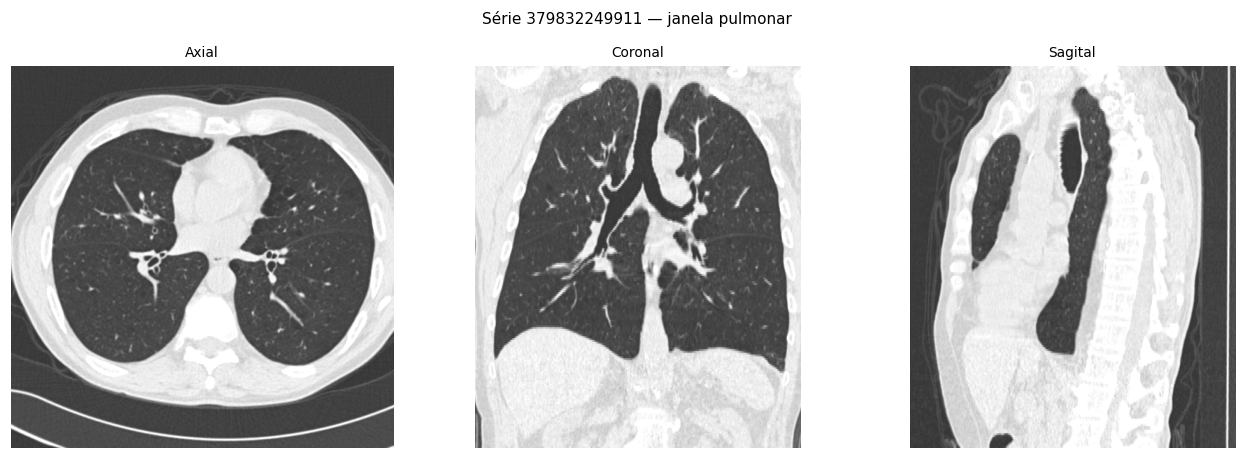

In [ ]:
VMIN, VMAX = -600 - 1500 / 2, -600 + 1500 / 2      # janela pulmonar


def ver_tres_planos(hu, espacamento, titulo=''):
    sx, sy, sz = espacamento
    nz, ny, nx = hu.shape
    planos = [('Axial', hu[nz // 2], sy / sx),
              ('Coronal', hu[::-1, ny // 2, :], sz / sx),
              ('Sagital', hu[::-1, :, nx // 2], sz / sy)]
    fig, eixos = plt.subplots(1, 3, figsize=(12, 4.2))
    for ax, (nome, img, aspecto) in zip(eixos, planos):
        ax.imshow(img, cmap='gray', vmin=VMIN, vmax=VMAX, aspect=aspecto)
        ax.set_title(nome, fontsize=9)
        ax.axis('off')
    fig.suptitle(titulo, fontsize=10)
    plt.tight_layout()
    plt.show()


ver_tres_planos(hu, meta['espacamento'], f'Série {uid_demo[-12:]} — janela pulmonar')

## Passo 7 — A escala HU: onde fica o pulmão

A escala é calibrada em dois pontos: água = 0 HU, ar = −1000 HU. O parênquima pulmonar não
é ar puro — é ar, sangue e interstício misturados — e sua densidade média fica entre
**−700 e −500 HU**.

O histograma mostra dois picos: um perto de −800 HU (ar pulmonar **e** ar fora do paciente,
que são indistinguíveis por intensidade) e outro perto de 0 HU (tecido mole). O vale entre
eles, em torno de −500 HU, é o que justifica pôr o limiar do baseline nessa região.

Antes disso, descartamos o *padding*: os cantos fora do círculo de reconstrução recebem um
valor sentinela (−2048, −2000 ou −3024, conforme o fabricante) que não é tecido.

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Padding: 0 voxels (0.0% do volume), valor dominante nan HU


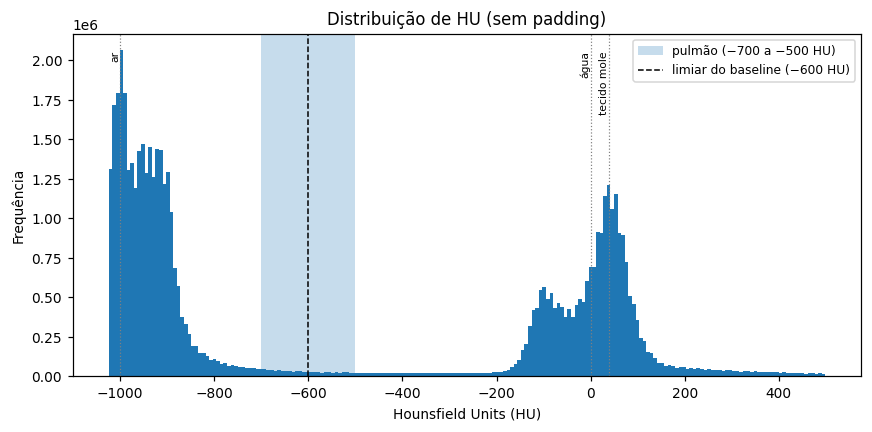

Voxels na faixa −700 a −500 HU: 773,054 (1.4%)


In [ ]:
padding = hu <= -1100
print(f'Padding: {padding.sum():,} voxels ({100*padding.mean():.1f}% do volume), '
      f'valor dominante {np.median(hu[padding]):.0f} HU')

validos = hu[~padding]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(validos[(validos > -1050) & (validos < 500)], bins=200)
ax.axvspan(-700, -500, alpha=0.25, label='pulmão (−700 a −500 HU)')
ax.axvline(LIMIAR_BASELINE, color='k', ls='--', lw=1, label='limiar do baseline (−600 HU)')
for valor, nome in [(-1000, 'ar'), (0, 'água'), (40, 'tecido mole')]:
    ax.axvline(valor, color='gray', ls=':', lw=0.8)
    ax.text(valor, ax.get_ylim()[1] * 0.95, nome, rotation=90, fontsize=7, ha='right', va='top')
ax.set_xlabel('Hounsfield Units (HU)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de HU (sem padding)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

faixa = (hu >= -700) & (hu <= -500)
print(f'Voxels na faixa −700 a −500 HU: {faixa.sum():,} ({100*faixa.mean():.1f}%)')

## Passo 8 — Método A: baseline (−600 HU + erosão)

$$A = \varepsilon\big(\{\,v : \mathrm{HU}(v) < -600\,\}\big)$$

Tudo abaixo de −600 HU vira "pulmão"; a erosão remove estruturas finas. Não há nenhuma
restrição espacial — e é justamente isso que vamos medir, porque **o ar fora do paciente
também está em −1000 HU** e satisfaz o mesmo critério.

Sobre a erosão: usamos `iterations=2` com vizinhança de 6, equivalente a um elemento
estruturante em losango de raio 2. É mais rápido que uma esfera e suficiente aqui.

In [ ]:
VIZ6 = ndi.generate_binary_structure(3, 1)


def volume_ml(mascara, vox=None):
    return float(mascara.sum() * (vox or VOX) / 1000)


def metodo_A(hu, limiar=LIMIAR_BASELINE, raio=RAIO_EROSAO):
    mascara = hu < limiar
    if raio:
        mascara = ndi.binary_erosion(mascara, VIZ6, iterations=raio)
    return mascara


mask_A = metodo_A(hu)
print(f'Método A — volume segmentado: {volume_ml(mask_A):,.0f} mL')
print('Para comparação: os dois pulmões de um adulto somam algo entre 3.000 e 6.000 mL.')

Método A — volume segmentado: 18,558 mL
Para comparação: os dois pulmões de um adulto somam algo entre 3.000 e 6.000 mL.


O volume é grande demais para ser pulmão. A figura abaixo mostra por quê.

> **Detalhe que estraga a figura:** passar a máscara booleana direto ao `imshow` com
> `alpha` pinta a imagem inteira, porque os pixels `False` recebem a cor mais clara do
> colormap em vez de ficarem transparentes. É preciso mascará-los com `np.ma.masked_where`.

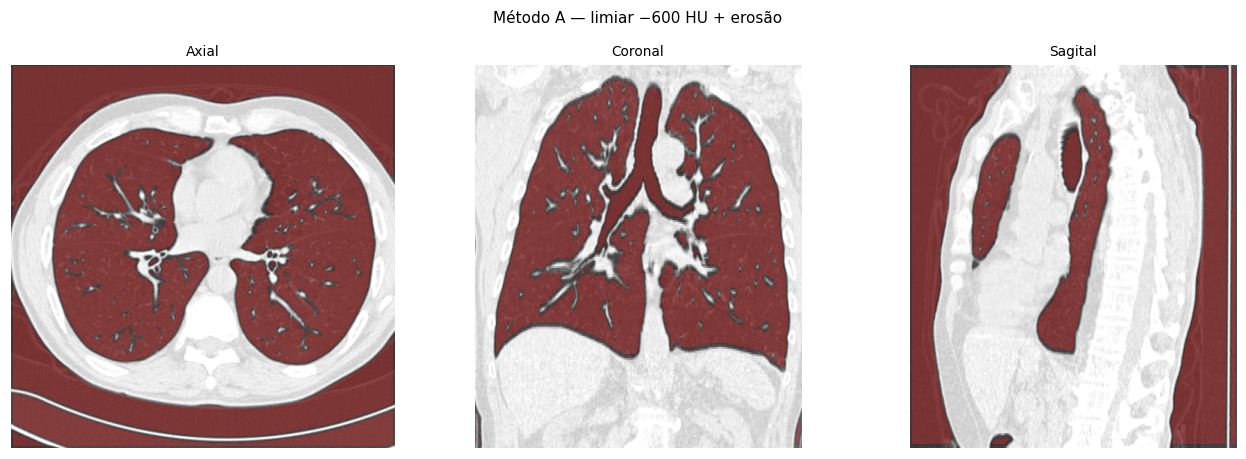

In [ ]:
def sobrepor(ax, fundo, mascara, cor, aspecto=1.0, titulo=''):
    ax.imshow(fundo, cmap='gray', vmin=VMIN, vmax=VMAX, aspect=aspecto)
    camada = np.ma.masked_where(~mascara, mascara.astype(float))
    ax.imshow(camada, alpha=0.4, aspect=aspecto, vmin=0, vmax=1,
              cmap=ListedColormap([cor]))
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')


def ver_mascara(hu, mascara, espacamento, cor='tab:red', titulo=''):
    sx, sy, sz = espacamento
    nz, ny, nx = hu.shape
    planos = [('Axial', hu[nz // 2], mascara[nz // 2], sy / sx),
              ('Coronal', hu[::-1, ny // 2, :], mascara[::-1, ny // 2, :], sz / sx),
              ('Sagital', hu[::-1, :, nx // 2], mascara[::-1, :, nx // 2], sz / sy)]
    fig, eixos = plt.subplots(1, 3, figsize=(12, 4.2))
    for ax, (nome, fundo, m, aspecto) in zip(eixos, planos):
        sobrepor(ax, fundo, m, cor, aspecto, nome)
    fig.suptitle(titulo, fontsize=10)
    plt.tight_layout()
    plt.show()


ver_mascara(hu, mask_A, meta['espacamento'], 'tab:red', 'Método A — limiar −600 HU + erosão')

O erro é claro: a máscara cobre todo o ar ao redor do paciente. Os pulmões estão lá dentro,
mas acompanhados de um volume muito maior de fundo.

A informação que falta não é de intensidade — é **espacial**. É isso que o método B usa.

## Passo 9 — Método B: crescimento de região + reconstrução morfológica

Três etapas, cada uma resolvendo um problema concreto do método A:

**1. Máscara do corpo.** Tudo acima de −320 HU, com cavidades preenchidas, ficando só o
maior objeto conectado: o paciente. Antes de crescer a região, os voxels fora do corpo
recebem HU alto. Assim o vazamento para o ar externo não é corrigido depois — fica
impossível por construção.

**2. Crescimento de região 3D** (`sitk.ConnectedThreshold`). A partir de sementes, agrega
vizinhos entre −1100 e −400 HU. A diferença para o limiar puro é a exigência de estar
**conectado à semente**: uma região de mesma intensidade, porém separada, não entra.

*Onde colocar as sementes?* O costume é usar a traqueia, no topo do volume — o que supõe
conhecer a orientação das fatias, algo que varia dentro do LIDC-IDRI. Aqui a semente é o
ponto mais interno de cada hemitórax, dado pelo máximo da transformada de distância do ar
dentro do corpo, em três alturas. Não depende de orientação.

**3. Reconstrução morfológica.** Vasos e nódulos estão acima de −400 HU e viram buracos na
máscara. Preenchê-los fatia a fatia recupera o interior; o fechamento seguinte restaura a
borda pleural.

Sementes (x, y, z): [(138, 206, 70), (396, 334, 70), (157, 188, 73), (429, 319, 73), (166, 310, 135), (382, 157, 135)]
Método A —   18,558 mL
Método B —    7,769 mL


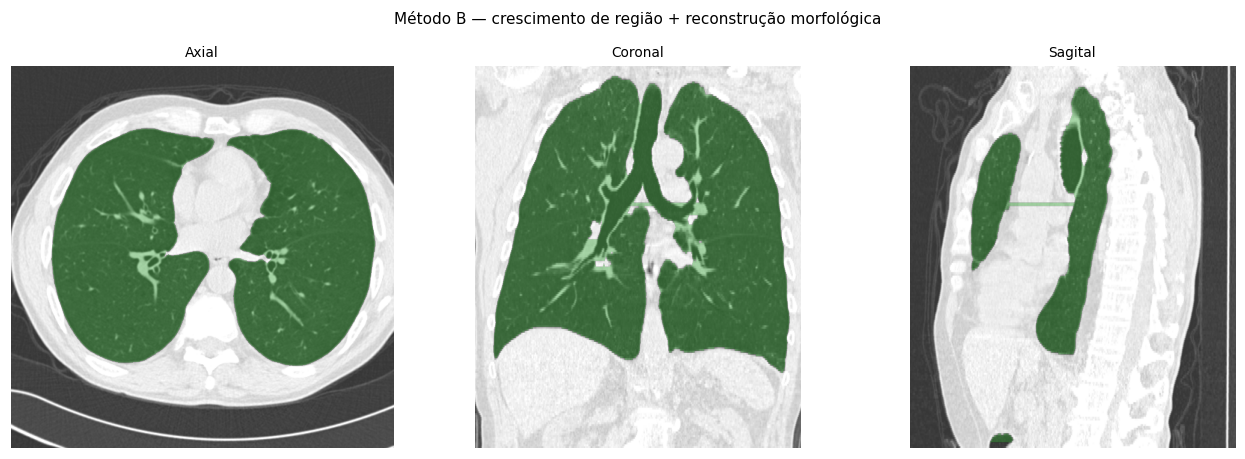

In [ ]:
def maior_componente(mascara, n=1):
    if not mascara.any():
        return mascara
    rotulos, k = ndi.label(mascara, VIZ6)
    tamanhos = ndi.sum_labels(mascara, rotulos, index=np.arange(1, k + 1))
    return np.isin(rotulos, np.argsort(tamanhos)[::-1][:n] + 1)


def remover_pequenos(mascara, vox, min_ml):
    if not mascara.any():
        return mascara
    rotulos, k = ndi.label(mascara, VIZ6)
    tamanhos = ndi.sum_labels(mascara, rotulos, index=np.arange(1, k + 1))
    manter = np.where(tamanhos * vox / 1000 >= min_ml)[0] + 1
    return np.isin(rotulos, manter)


def preencher_cavidades(mascara):
    '''Preenche buracos fatia a fatia — é a reconstrução morfológica do fundo.'''
    return np.stack([ndi.binary_fill_holes(f) for f in mascara])


def mascara_corpo(hu):
    corpo = preencher_cavidades(hu > LIMIAR_TECIDO)
    corpo = maior_componente(corpo)
    corpo = ndi.binary_closing(corpo, VIZ6, iterations=2)
    return preencher_cavidades(corpo)


def achar_sementes(ar_interno):
    '''Ponto mais interno de cada hemitórax, em três alturas do volume.'''
    nz = ar_interno.shape[0]
    areas = ar_interno.reshape(nz, -1).sum(axis=1)
    if areas.max() == 0:
        return []
    sementes = []
    for z in sorted({int(np.argmax(areas)), int(nz * 0.35), int(nz * 0.65)}):
        fatia = ar_interno[z]
        if not fatia.any():
            continue
        meio = int(round(ndi.center_of_mass(fatia)[1]))
        for x0, x1 in ((0, meio), (meio, fatia.shape[1])):
            metade = np.zeros_like(fatia)
            metade[:, x0:x1] = fatia[:, x0:x1]
            if not metade.any():
                continue
            dist = ndi.distance_transform_edt(metade)
            if dist.max() < 3:
                continue
            y, x = np.unravel_index(np.argmax(dist), dist.shape)
            if (int(x), int(y), int(z)) not in sementes:
                sementes.append((int(x), int(y), int(z)))
    return sementes


def metodo_B(hu, vox, confinar=True, preencher=True, fechar=True,
             retornar_sementes=False):
    '''Crescimento de região 3D + reconstrução morfológica.

    Os três interruptores existem para a ablação do Passo 14: cada um liga ou
    desliga uma etapa de pré/pós-processamento, mantendo o resto igual.
    '''
    corpo = mascara_corpo(hu)
    ar_interno = remover_pequenos((hu < LIMIAR_AR) & corpo, vox, 5.0)

    sementes = achar_sementes(ar_interno)
    if not sementes:
        vazio = np.zeros_like(hu, dtype=bool)
        return (vazio, []) if retornar_sementes else vazio

    # confinamento: fora do corpo vira tecido denso, travando o vazamento
    entrada = np.where(corpo, hu, 1000.0).astype(np.float32) if confinar else hu.astype(np.float32)
    crescida = sitk.ConnectedThreshold(sitk.GetImageFromArray(entrada),
                                       seedList=sementes,
                                       lower=LIMIAR_INFERIOR, upper=LIMIAR_AR)
    mascara = sitk.GetArrayFromImage(crescida).astype(bool)

    if preencher:
        mascara = preencher_cavidades(mascara)                      # vasos e nódulos
    if fechar:
        mascara = ndi.binary_closing(mascara, VIZ6, iterations=RAIO_FECHAMENTO)
        if preencher:
            mascara = preencher_cavidades(mascara)                  # borda pleural
    if confinar:
        mascara &= corpo
    mascara = remover_pequenos(mascara, vox, VOLUME_MINIMO_ML)
    return (mascara, sementes) if retornar_sementes else mascara


mask_B, sementes = metodo_B(hu, VOX, retornar_sementes=True)
print('Sementes (x, y, z):', sementes)
print(f'Método A — {volume_ml(mask_A):8,.0f} mL')
print(f'Método B — {volume_ml(mask_B):8,.0f} mL')

ver_mascara(hu, mask_B, meta['espacamento'], 'tab:green',
            'Método B — crescimento de região + reconstrução morfológica')

## Passo 10 — Máscara de referência e métricas

Os arquivos do LUNA16 não são binários: **3** é o pulmão esquerdo, **4** o direito e **5** a
traqueia. A célula imprime os rótulos que realmente aparecem, para conferir.

Antes de comparar, a máscara é **reamostrada para a grade da TC**. Comparar dois arrays
voxel a voxel só vale se tamanho, espaçamento, origem e direção coincidirem; a reamostragem
com vizinho mais próximo resolve diferenças de origem e de ordem das fatias usando as
coordenadas físicas do DICOM, sem inventar valores de rótulo.

As métricas, para predição $P$ e referência $R$:

$$\mathrm{Dice} = \frac{2|P \cap R|}{|P| + |R|}
\qquad
\mathrm{IoU} = \frac{|P \cap R|}{|P \cup R|}
\qquad
\mathrm{Dice} = \frac{2\,\mathrm{IoU}}{1 + \mathrm{IoU}}$$

As duas são matematicamente equivalentes na ordenação dos métodos; o IoU é mais severo com
sobreposições parciais. As secundárias separam os dois tipos de erro que o Dice junta:

$$\mathrm{Sens} = \frac{|P \cap R|}{|R|}
\quad\text{(quanto do pulmão foi achado)}
\qquad
\mathrm{Prec} = \frac{|P \cap R|}{|P|}
\quad\text{(quanto do achado é pulmão)}$$

Calculamos também a **acurácia por pixel** — não porque ela sirva para avaliar, mas
exatamente para mostrar, no Passo 13, por que ela não serve.

In [ ]:
def carregar_referencia(uid, tc):
    mascara = sitk.ReadImage(str(mascaras[uid]))
    mesma_grade = (mascara.GetSize() == tc.GetSize()
                   and np.allclose(mascara.GetSpacing(), tc.GetSpacing(), atol=1e-3)
                   and np.allclose(mascara.GetOrigin(), tc.GetOrigin(), atol=1e-2)
                   and np.allclose(mascara.GetDirection(), tc.GetDirection(), atol=1e-3))
    if not mesma_grade:
        mascara = sitk.Resample(mascara, tc, sitk.Transform(),
                                sitk.sitkNearestNeighbor, 0.0, mascara.GetPixelID())
    arr = sitk.GetArrayFromImage(mascara)
    binaria = np.isin(arr, ROTULOS_PULMAO)
    return binaria if binaria.any() else arr > 0


def metricas(pred, ref, vox):
    inter = float(np.logical_and(pred, ref).sum())
    np_, nr = float(pred.sum()), float(ref.sum())
    total = float(pred.size)
    vn = total - np_ - nr + inter                       # verdadeiros negativos
    return {'dice': 2 * inter / (np_ + nr) if np_ + nr else 1.0,
            'iou': inter / (np_ + nr - inter) if np_ + nr - inter else 1.0,
            'sensibilidade': inter / nr if nr else np.nan,
            'precisao': inter / np_ if np_ else np.nan,
            'acuracia': (inter + vn) / total,
            'acuracia_trivial': (total - nr) / total,   # prever "tudo é fundo"
            'erro_volume_pct': 100 * (np_ - nr) / nr if nr else np.nan}


bruta = sitk.GetArrayFromImage(sitk.ReadImage(str(mascaras[uid_demo])))
valores, contagens = np.unique(bruta, return_counts=True)
print('Rótulos na máscara:', dict(zip(valores.tolist(), contagens.tolist())))

ref = carregar_referencia(uid_demo, tc)
print(f'Referência — volume: {volume_ml(ref):,.0f} mL')
print()
for nome, pred in [('A', mask_A), ('B', mask_B)]:
    m = metricas(pred, ref, VOX)
    print(f"Método {nome}:  Dice={m['dice']:.3f}  IoU={m['iou']:.3f}  "
          f"Sens={m['sensibilidade']:.3f}  Prec={m['precisao']:.3f}")

Rótulos na máscara: {0: 44060112, 3: 5245011, 4: 5391236, 5: 91737}
Referência — volume: 7,479 mL

Método A:  Dice=0.461  IoU=0.300  Sens=0.803  Prec=0.323
Método B:  Dice=0.975  IoU=0.951  Sens=0.994  Prec=0.957


### Onde estão os erros

Um escalar diz *quanto* erramos; o mapa abaixo diz *onde*.

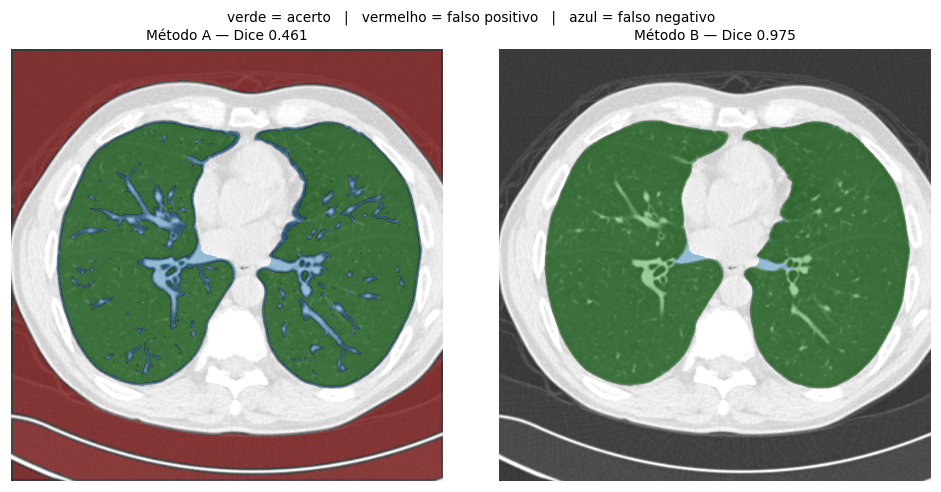

In [ ]:
def mapa_erros(ax, fundo, pred, ref, aspecto=1.0, titulo=''):
    ax.imshow(fundo, cmap='gray', vmin=VMIN, vmax=VMAX, aspect=aspecto)
    camadas = {'tab:green': pred & ref,          # acerto
               'tab:red': pred & ~ref,           # falso positivo
               'tab:blue': ~pred & ref}          # falso negativo
    for cor, camada in camadas.items():
        ax.imshow(np.ma.masked_where(~camada, camada.astype(float)),
                  alpha=0.45, aspect=aspecto, vmin=0, vmax=1, cmap=ListedColormap([cor]))
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')


z = hu.shape[0] // 2
sx, sy, _ = meta['espacamento']
fig, eixos = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (nome, pred) in zip(eixos, [('A', mask_A), ('B', mask_B)]):
    d = metricas(pred, ref, VOX)['dice']
    mapa_erros(ax, hu[z], pred[z], ref[z], sy / sx, f'Método {nome} — Dice {d:.3f}')
fig.suptitle('verde = acerto   |   vermelho = falso positivo   |   azul = falso negativo',
             fontsize=9)
plt.tight_layout()
plt.show()

## Passo 11 — Rodar nos 20 exames

Um exame por vez: 20 volumes na memória ao mesmo tempo estouram a RAM do Colab. Falhas
individuais são registradas e não interrompem o experimento — por isso a fila tem séries de
reserva.

**Tempo por TC.** Cronometramos apenas a segmentação, não o download nem a leitura do
DICOM, porque é o custo do *método* que interessa comparar. O tempo do Colab varia entre
sessões, então o número serve para comparar A com B, não como referência absoluta.

Junto das métricas guardamos dois descritores de cada exame, usados na análise de falhas:
o HU médio dentro da referência e a fração dela acima de −500 HU. Os dois medem quanto do
"pulmão" daquele paciente deixou de ser ar.

In [ ]:
def avaliar(uid):
    tc, meta = carregar_tc(pasta_da_serie(uid))
    hu = sitk.GetArrayFromImage(tc)
    vox = meta['volume_voxel_mm3']
    ref = carregar_referencia(uid, tc)
    if not ref.any():
        raise RuntimeError('Referência vazia após alinhamento.')

    hu_ref = hu[ref]
    linha = {'uid': uid, 'espessura_mm': meta['espessura_mm'], 'n_fatias': meta['n_fatias'],
             'volume_ref_ml': volume_ml(ref, vox),
             'hu_medio_pulmao': float(hu_ref.mean()),
             'frac_acima_500': float((hu_ref > -500).mean())}

    for nome, funcao in [('A', lambda: metodo_A(hu)), ('B', lambda: metodo_B(hu, vox))]:
        t0 = time.perf_counter()
        pred = funcao()
        linha[f'{nome}_tempo_s'] = time.perf_counter() - t0     # só a segmentação
        for chave, valor in metricas(pred, ref, vox).items():
            linha[f'{nome}_{chave}'] = valor
    return linha


arquivo_csv = DIR_RESULTADOS / 'metricas.csv'

if arquivo_csv.exists():
    resultados = pd.read_csv(arquivo_csv)
    print(f'Resultados lidos do disco: {len(resultados)} exames.')
else:
    linhas, falhas = [], []
    for uid in fila:
        if len(linhas) >= N_SERIES:
            break
        t0 = time.time()
        try:
            linhas.append(avaliar(uid))
            print(f"[{len(linhas):2d}/{N_SERIES}] {uid[-12:]}  "
                  f"Dice A={linhas[-1]['A_dice']:.3f}  B={linhas[-1]['B_dice']:.3f}  "
                  f"({time.time()-t0:.0f}s)")
        except Exception as e:
            falhas.append({'uid': uid, 'erro': repr(e)})
            print(f'[--/{N_SERIES}] {uid[-12:]}  FALHOU: {e}')
    resultados = pd.DataFrame(linhas)
    resultados.to_csv(arquivo_csv, index=False)
    if falhas:
        pd.DataFrame(falhas).to_csv(DIR_RESULTADOS / 'falhas.csv', index=False)

print(f'\nExames avaliados: {len(resultados)}')
if len(resultados) < N_SERIES:
    raise RuntimeError(f'Menos de {N_SERIES} exames. Veja falhas.csv, aumente N_RESERVA '
                       'e apague amostra_uids.json e metricas.csv antes de repetir.')

[ 1/20] 379832249911  Dice A=0.461  B=0.975  (29s)
[ 2/20] 493757419144  Dice A=0.115  B=0.985  (53s)
[ 3/20] 834210228428  Dice A=0.273  B=0.982  (49s)
[ 4/20] 202941034290  Dice A=0.333  B=0.984  (81s)
[ 5/20] 285870245028  Dice A=0.353  B=0.985  (54s)
[ 6/20] 480563388746  Dice A=0.144  B=0.986  (29s)
[ 7/20] 151738328001  Dice A=0.213  B=0.987  (49s)
[ 8/20] 826189754230  Dice A=0.213  B=0.985  (26s)
[ 9/20] 689307479986  Dice A=0.378  B=0.987  (41s)
[10/20] 758082619196  Dice A=0.083  B=0.666  (27s)
[11/20] 213579659366  Dice A=0.427  B=0.990  (44s)
[12/20] 525232698200  Dice A=0.394  B=0.987  (109s)
[13/20] 876304987559  Dice A=0.261  B=0.984  (70s)
[14/20] 729469324839  Dice A=0.315  B=0.988  (77s)
[15/20] 277400089532  Dice A=0.325  B=0.987  (30s)
[16/20] 649939526179  Dice A=0.323  B=0.984  (67s)
[17/20] 907954580114  Dice A=0.189  B=0.979  (26s)
[18/20] 516219450076  Dice A=0.225  B=0.985  (34s)
[19/20] 697302970157  Dice A=0.108  B=0.983  (28s)
[20/20] 031293531091  Dice A=0

## Passo 12 — Resultados com intervalo de confiança

Reportamos média e **IC 95% por bootstrap** com 1.000 reamostragens.

Por que bootstrap e não o intervalo normal: o Dice é limitado a $[0,1]$ e, quando os valores
se concentram perto do teto, a distribuição fica assimétrica e o intervalo normal chega a
ultrapassar 1,0 — um limite superior que não existe. O bootstrap reamostra os 20 exames com
reposição e lê os percentis 2,5 e 97,5 da distribuição das médias, respeitando o suporte da
métrica.

Com n = 20 o intervalo é largo. Isso não é defeito do cálculo: é a incerteza real de uma
amostra pequena, que o número único da média esconde.

In [ ]:
N_BOOTSTRAP = 1000          # a rubrica exige no mínimo 500
METAS = {'dice': 0.85, 'iou': 0.75}


def ic_bootstrap(valores, n=N_BOOTSTRAP, alfa=0.05, semente=SEED):
    v = np.asarray(valores, float)
    v = v[~np.isnan(v)]
    rng = np.random.default_rng(semente)
    medias = rng.choice(v, size=(n, v.size), replace=True).mean(axis=1)
    return np.percentile(medias, [100 * alfa / 2, 100 * (1 - alfa / 2)])


def linha_resumo(k, nome):
    linha = {'método': nome}
    for metrica, rotulo in [('dice', 'Dice'), ('iou', 'IoU'),
                            ('sensibilidade', 'Sens.'), ('precisao', 'Precisão')]:
        v = resultados[f'{k}_{metrica}']
        lo, hi = ic_bootstrap(v)
        linha[rotulo] = f'{v.mean():.3f} [{lo:.3f}–{hi:.3f}]'
    linha['Tempo/TC (s)'] = f"{resultados[f'{k}_tempo_s'].mean():.1f}"
    for metrica, meta in METAS.items():
        media = resultados[f'{k}_{metrica}'].mean()
        linha[f'Meta {metrica} ≥ {meta}'] = 'atingida' if media >= meta else 'não atingida'
    return linha


resumo = pd.DataFrame([linha_resumo('A', 'A — limiar −600 HU + erosão'),
                       linha_resumo('B', 'B — região + morfologia')])
display(resumo)
resumo.to_csv(DIR_RESULTADOS / 'resumo.csv', index=False)
print(f'Média [IC 95% por bootstrap, {N_BOOTSTRAP} reamostragens], n = {len(resultados)} exames.')

,método,Dice,IoU,Sens.,Precisão,Tempo/TC (s),Meta dice ≥ 0.85,Meta iou ≥ 0.75
0,A — limiar −600 HU + erosão,0.264 [0.221–0.313],0.157 [0.128–0.190],0.628 [0.581–0.675],0.172 [0.140–0.209],1.6,não atingida,não atingida
1,B — região + morfologia,0.969 [0.936–0.986],0.946 [0.898–0.972],0.987 [0.985–0.989],0.958 [0.909–0.985],24.7,atingida,atingida


Média [IC 95% por bootstrap, 1000 reamostragens], n = 20 exames.


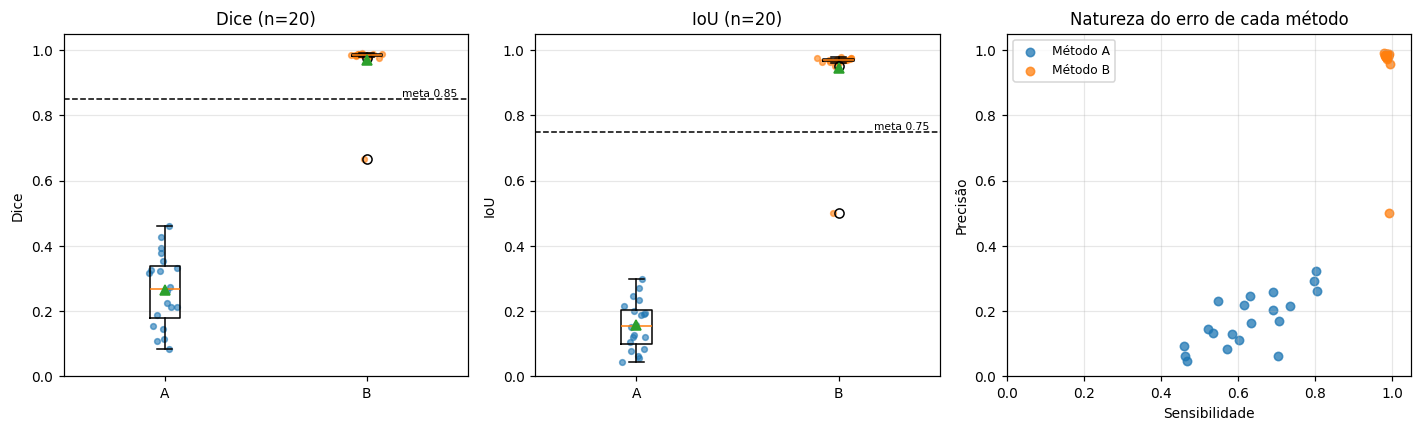

In [ ]:
fig, eixos = plt.subplots(1, 3, figsize=(13, 4))

for ax, metrica, rotulo in zip(eixos[:2], ['dice', 'iou'], ['Dice', 'IoU']):
    dados = [resultados[f'{k}_{metrica}'].values for k in ('A', 'B')]
    ax.boxplot(dados, showmeans=True)
    ax.set_xticks([1, 2], ['A', 'B'])
    for i, d in enumerate(dados, 1):
        ax.scatter(np.random.normal(i, 0.04, len(d)), d, s=14, alpha=0.6)
    ax.axhline(METAS[metrica], ls='--', lw=1, color='k')
    ax.text(2.45, METAS[metrica], f'meta {METAS[metrica]}', fontsize=7, va='bottom', ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(rotulo)
    ax.set_title(f'{rotulo} (n={len(resultados)})')
    ax.grid(axis='y', alpha=0.3)

# sensibilidade x precisão: os dois métodos erram de formas diferentes
for k, nome in [('A', 'Método A'), ('B', 'Método B')]:
    eixos[2].scatter(resultados[f'{k}_sensibilidade'], resultados[f'{k}_precisao'],
                     s=30, alpha=0.75, label=nome)
eixos[2].set_xlabel('Sensibilidade')
eixos[2].set_ylabel('Precisão')
eixos[2].set_xlim(0, 1.05)
eixos[2].set_ylim(0, 1.05)
eixos[2].legend(fontsize=8)
eixos[2].grid(alpha=0.3)
eixos[2].set_title('Natureza do erro de cada método')

plt.tight_layout()
plt.show()

## Passo 13 — Por que acurácia engana

Os pulmões ocupam algo entre 8% e 15% dos voxels de uma TC de tórax. Um classificador
trivial que responde **"nada é pulmão"** para todos os voxels acerta os outros 85% a 92% —
e não segmenta absolutamente nada.

Isso não é um exercício retórico: dá para calcular com os dados desta avaliação. A célula
abaixo compara a acurácia dos dois métodos com a do classificador trivial.

O mesmo raciocínio, aplicado a rastreamento de câncer, é mais grave. Como a prevalência de
nódulos malignos é baixa, um classificador que sempre responde "benigno" atinge acurácia
alta **perdendo todos os casos malignos**. Por isso a acurácia não entra na avaliação deste
trabalho, e as métricas primárias são Dice e IoU, que só sobem quando há sobreposição real
com o alvo.

In [ ]:
comparacao = pd.DataFrame([
    {'classificador': 'Trivial ("nada é pulmão")',
     'Acurácia': resultados['A_acuracia_trivial'].mean(),
     'Dice': 0.0, 'Sensibilidade': 0.0},
    {'classificador': 'Método A',
     'Acurácia': resultados['A_acuracia'].mean(),
     'Dice': resultados['A_dice'].mean(),
     'Sensibilidade': resultados['A_sensibilidade'].mean()},
    {'classificador': 'Método B',
     'Acurácia': resultados['B_acuracia'].mean(),
     'Dice': resultados['B_dice'].mean(),
     'Sensibilidade': resultados['B_sensibilidade'].mean()},
])
display(comparacao.round(3))

trivial = resultados['A_acuracia_trivial'].mean()
print(f'\nO classificador trivial acerta {100*trivial:.1f}% dos voxels e tem Dice = 0.')
print(f'A fração de voxels que é pulmão na referência: {100*(1-trivial):.1f}%.')

,classificador,Acurácia,Dice,Sensibilidade
0,"Trivial (""nada é pulmão"")",0.880,0.000,0.000
1,Método A,0.572,0.264,0.628
2,Método B,0.994,0.969,0.987



O classificador trivial acerta 88.0% dos voxels e tem Dice = 0.
A fração de voxels que é pulmão na referência: 12.0%.


## Passo 14 — Quanto o pré-processamento explica do desempenho

O método B usa o **mesmo critério de intensidade** do método A. O que muda é o que existe em
volta: a máscara de corpo, a exigência de conectividade e a reconstrução morfológica. O salto
de Dice entre A e B, medido no Passo 12, é portanto o efeito do pré-processamento — nenhum
limiar novo foi introduzido.

A ablação abaixo refina essa medida dentro do próprio método B, desligando uma etapa por vez:

1. **confinamento ao corpo** — impede o vazamento do crescimento para o ar externo;
2. **preenchimento de cavidades** — recupera vasos e nódulos internos;
3. **fechamento morfológico** — restaura a borda pleural.

**Leia a tabela antes de concluir.** É possível que alguma etapa mude pouco: o confinamento,
por exemplo, só age quando existe um caminho conectando o pulmão ao ar externo dentro do
volume, o que nem sempre acontece. Uma etapa com efeito pequeno não é inútil — é uma proteção
contra um caso que aquela amostra não continha. Relatar isso é mais informativo do que
apresentar cada componente como essencial.

Roda em 5 exames para não custar caro; as séries já estão em cache do Passo 11.


,dice,iou,sensibilidade,precisao,queda no Dice
variante,,,,,
B completo,0.982,0.965,0.988,0.976,0.000
sem confinamento ao corpo,0.982,0.965,0.988,0.976,0.000
sem preenchimento de cavidades,0.982,0.964,0.985,0.979,0.000
sem fechamento morfológico,0.980,0.962,0.982,0.978,0.002
só crescimento de região,0.973,0.948,0.967,0.980,0.009
(referência) método A,0.307,NaN,NaN,NaN,NaN


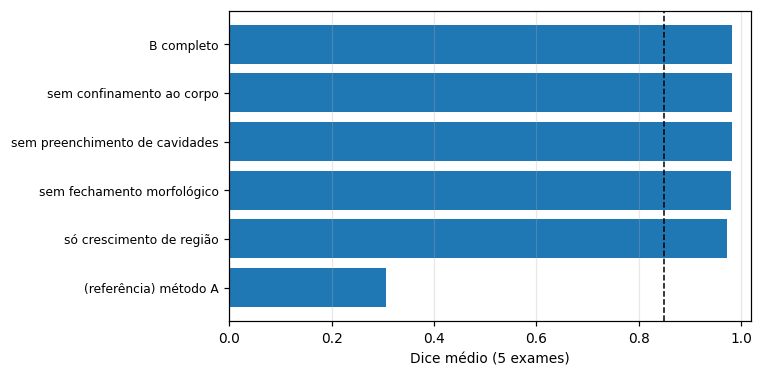

In [ ]:
VARIANTES = {
    'B completo': dict(),
    'sem confinamento ao corpo': dict(confinar=False),
    'sem preenchimento de cavidades': dict(preencher=False),
    'sem fechamento morfológico': dict(fechar=False),
    'só crescimento de região': dict(confinar=False, preencher=False, fechar=False),
}

arquivo_ablacao = DIR_RESULTADOS / 'ablacao.csv'

if arquivo_ablacao.exists():
    ablacao = pd.read_csv(arquivo_ablacao)
else:
    registros = []
    for uid in resultados['uid'].head(5):
        tc, meta = carregar_tc(pasta_da_serie(uid))
        hu_i = sitk.GetArrayFromImage(tc)
        vox_i = meta['volume_voxel_mm3']
        ref_i = carregar_referencia(uid, tc)
        for nome, kwargs in VARIANTES.items():
            pred = metodo_B(hu_i, vox_i, **kwargs)
            m = metricas(pred, ref_i, vox_i)
            registros.append({'uid': uid, 'variante': nome, 'dice': m['dice'],
                              'iou': m['iou'], 'sensibilidade': m['sensibilidade'],
                              'precisao': m['precisao']})
        del hu_i, ref_i
    ablacao = pd.DataFrame(registros)
    ablacao.to_csv(arquivo_ablacao, index=False)

tabela_ablacao = (ablacao.groupby('variante')[['dice', 'iou', 'sensibilidade', 'precisao']]
                  .mean().reindex(VARIANTES.keys()).round(3))
tabela_ablacao['queda no Dice'] = (tabela_ablacao.loc['B completo', 'dice']
                                   - tabela_ablacao['dice']).round(3)
# linha de referência: o método A nos mesmos 5 exames
uids_ablacao = list(ablacao['uid'].unique())
tabela_ablacao.loc['(referência) método A', 'dice'] = round(
    resultados.set_index('uid').loc[uids_ablacao, 'A_dice'].mean(), 3)
display(tabela_ablacao)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(range(len(tabela_ablacao)), tabela_ablacao['dice'])
ax.set_yticks(range(len(tabela_ablacao)), tabela_ablacao.index, fontsize=8)
ax.invert_yaxis()
ax.axvline(METAS['dice'], ls='--', lw=1, color='k')
ax.set_xlabel('Dice médio (5 exames)')
ax.set_xlim(0, 1.02)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Passo 15 — Análise de falhas

### Onde o baseline falha sempre

O método A tem **sensibilidade alta e precisão baixa**: ele encontra o pulmão, mas não
consegue dizer o que *não* é pulmão. A causa é única e afeta todos os exames — o ar externo
está na mesma faixa de HU que o ar alveolar. Nenhum ajuste de limiar resolve isso, porque a
diferença entre os dois não é de intensidade.

### Onde qualquer método falha

Quando o parênquima deixa de ser ar. Derrame pleural, atelectasia e consolidação deslocam o
tecido pulmonar de −700 HU para perto de 0 HU, onde ele fica igual a músculo. A fração da
referência acima de −500 HU mede exatamente isso, e o gráfico testa se ela prevê a queda no
Dice.

### Qual dos dois erros custa mais

Falso positivo e falso negativo não se equivalem. Em segmentação usada como etapa anterior à
detecção de nódulos, **o falso negativo é o mais grave**: um pedaço de pulmão que ficou de
fora da máscara é uma região que o detector nunca vai examinar, e um nódulo ali é
simplesmente perdido. Um falso positivo — um pedaço de mediastino incluído — apenas dá
trabalho extra ao passo seguinte.

Por isso a **sensibilidade** é a métrica secundária prioritária, e por isso o método A, que
tem sensibilidade alta, não é inútil: ele erra do lado menos perigoso. O que o inviabiliza é
a precisão, que o torna caro para qualquer etapa posterior.

Essa assimetria é ainda mais forte no rastreamento de câncer, onde um falso negativo
significa mandar para casa um paciente com tumor. O ponto de operação nesses sistemas é
escolhido fixando a especificidade e maximizando a sensibilidade — nunca maximizando
acurácia.

Método A: Spearman ρ = -0.69  (p = 0.001)
Método B: Spearman ρ = -0.40  (p = 0.083)


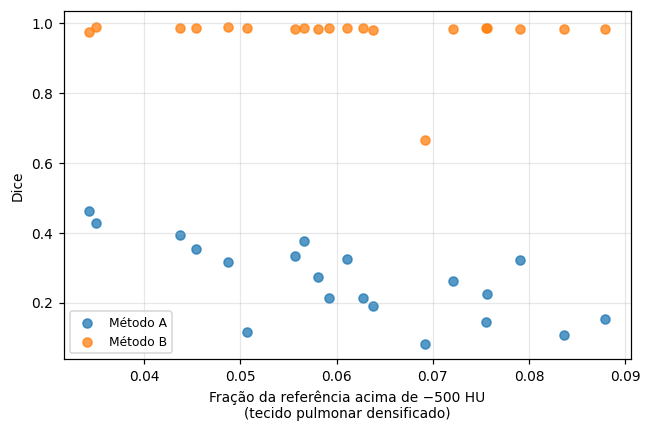


--- 3 piores casos (pelo método B) ---


,uid,A_dice,B_dice,B_sensibilidade,B_precisao,hu_medio_pulmao,frac_acima_500,espessura_mm
9,1.3.6.1.4.1.14519.5.2.1.6279.6001.202811684116...,0.083,0.666,0.993,0.501,-784.311,0.069,2.5
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.119515474430...,0.461,0.975,0.994,0.957,-876.097,0.034,2.0
16,1.3.6.1.4.1.14519.5.2.1.6279.6001.206028343897...,0.189,0.979,0.986,0.973,-752.222,0.064,2.5


In [ ]:
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(6, 4))
for k, nome in [('A', 'Método A'), ('B', 'Método B')]:
    ax.scatter(resultados['frac_acima_500'], resultados[f'{k}_dice'], s=35, alpha=0.75,
               label=nome)
    rho, p = spearmanr(resultados['frac_acima_500'], resultados[f'{k}_dice'])
    print(f'{nome}: Spearman ρ = {rho:+.2f}  (p = {p:.3f})')
ax.set_xlabel('Fração da referência acima de −500 HU\n(tecido pulmonar densificado)')
ax.set_ylabel('Dice')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

piores = resultados.nsmallest(3, 'B_dice')[
    ['uid', 'A_dice', 'B_dice', 'B_sensibilidade', 'B_precisao',
     'hu_medio_pulmao', 'frac_acima_500', 'espessura_mm']]
print('\n--- 3 piores casos (pelo método B) ---')
display(piores.round(3))

### Inspeção dos piores casos

Para cada um, mostramos a fatia de maior discordância e o histograma do conteúdo da
referência. Se o histograma tiver um segundo pico perto de 0 HU, há tecido densificado — e
o modo de falha é o da tabela seguinte.

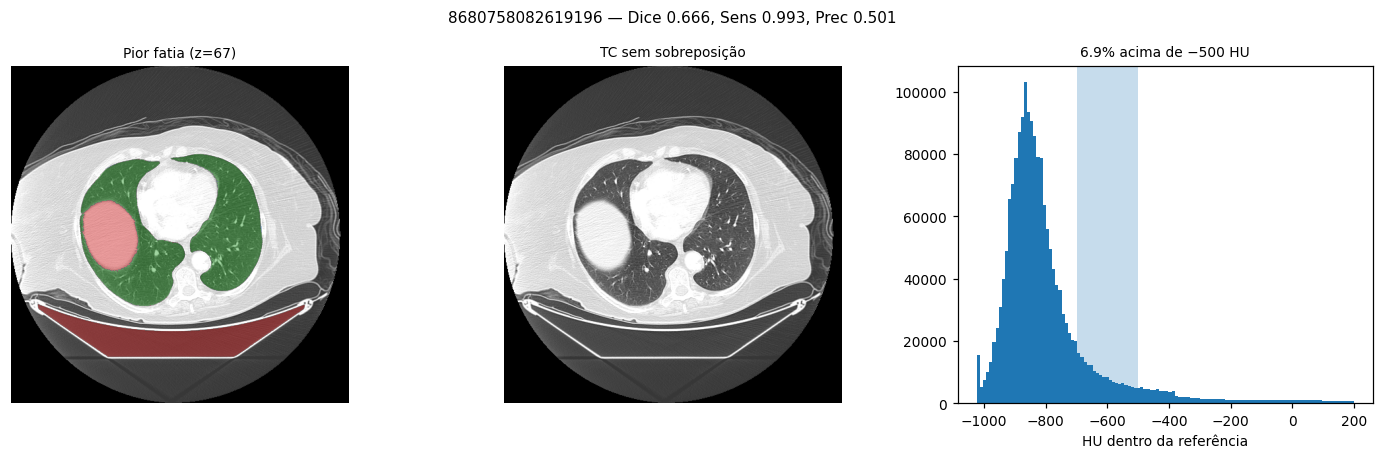

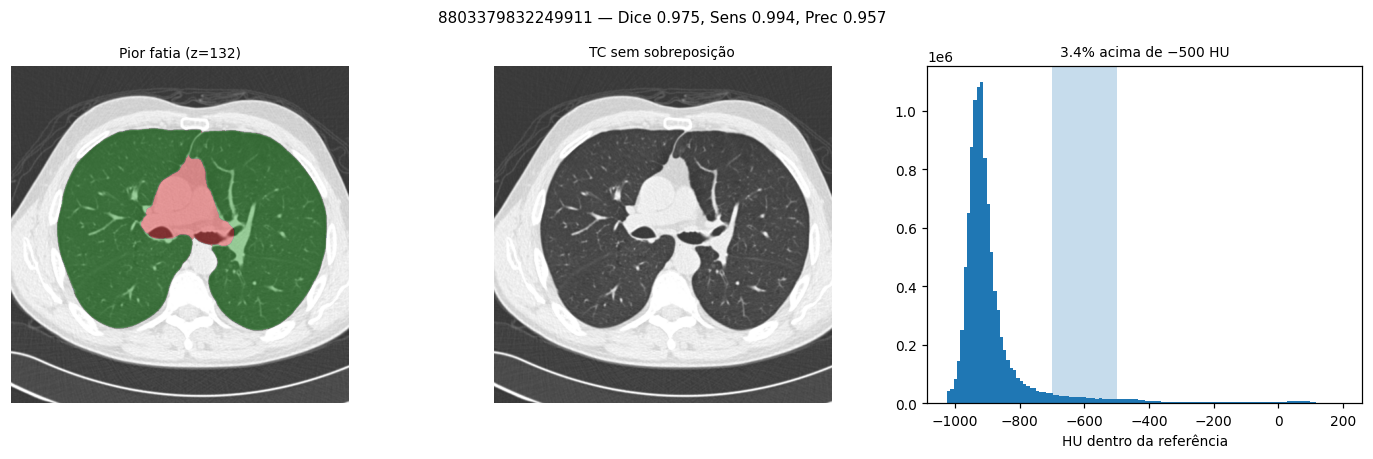

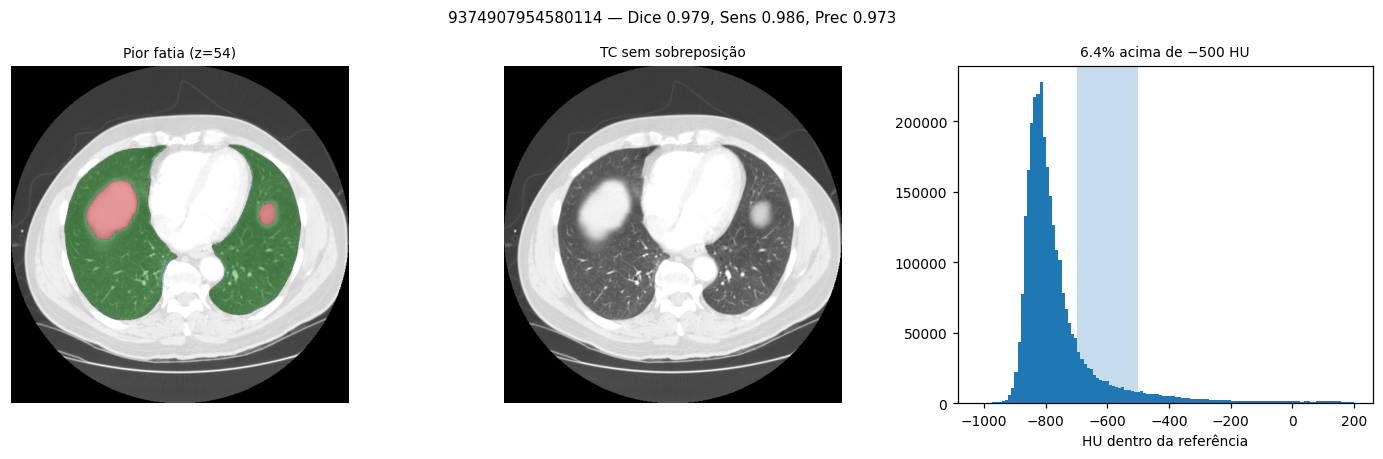

In [ ]:
def inspecionar(uid):
    tc, meta = carregar_tc(pasta_da_serie(uid))
    hu = sitk.GetArrayFromImage(tc)
    vox = meta['volume_voxel_mm3']
    ref = carregar_referencia(uid, tc)
    pred = metodo_B(hu, vox)

    discordancia = np.logical_xor(pred, ref).reshape(hu.shape[0], -1).sum(axis=1)
    z = int(np.argmax(discordancia))
    sx, sy, _ = meta['espacamento']
    m = metricas(pred, ref, vox)

    fig, eixos = plt.subplots(1, 3, figsize=(13, 4.2))
    mapa_erros(eixos[0], hu[z], pred[z], ref[z], sy / sx, f'Pior fatia (z={z})')
    eixos[1].imshow(hu[z], cmap='gray', vmin=VMIN, vmax=VMAX, aspect=sy / sx)
    eixos[1].set_title('TC sem sobreposição', fontsize=9)
    eixos[1].axis('off')
    hu_ref = hu[ref]
    eixos[2].hist(hu_ref[(hu_ref > -1100) & (hu_ref < 200)], bins=120)
    eixos[2].axvspan(-700, -500, alpha=0.25)
    eixos[2].set_xlabel('HU dentro da referência')
    eixos[2].set_title(f'{100*(hu_ref > -500).mean():.1f}% acima de −500 HU', fontsize=9)
    fig.suptitle(f"{uid[-16:]} — Dice {m['dice']:.3f}, Sens {m['sensibilidade']:.3f}, "
                 f"Prec {m['precisao']:.3f}", fontsize=10)
    plt.tight_layout()
    plt.show()


for uid in piores['uid']:
    inspecionar(uid)

## Passo 16 — Modos de falha

O que procurar nas figuras acima:

| Achado | HU típico | Como aparece no mapa de erros | Afeta |
|---|---|---|---|
| Ar externo ao paciente | ≈ −1000 | falso positivo (vermelho) extenso, fora do tórax | A |
| Derrame pleural | 0 a +20 | falso negativo (azul) em cunha, na região de baixo | A e B |
| Atelectasia / colapso | −100 a +50 | falso negativo lobar, com desvio das estruturas ao lado | A e B |
| Consolidação | −100 a +30 | falso negativo em placas | A e B |
| Nódulo justapleural | +30 a +80 | falso negativo pequeno na borda | B |
| Enfisema grave | < −950 | bolhas incluídas ou não, conforme a referência | A e B |
| Traqueia e brônquios | ≈ −1000 | falso positivo tubular no centro | B |
| Corte espesso (> 2,5 mm) | — | borda pleural mal definida | A e B |

A distinção que importa:

- **Ar externo** e **traqueia** são falhas de *especificação*. O método pediu a coisa
  errada e dá para corrigir com restrição geométrica — é o que o método B faz.
- **Derrame, atelectasia e consolidação** são falhas de *premissa*. O tecido deixou de ser
  ar, e nenhum limiar o recupera, porque a informação que o identificaria como pulmão é
  anatômica, não radiométrica.

É por isso que o passo seguinte natural são redes que aprendem forma: uma U-Net treinada
aprende que a região densa e em cunha no fundo do tórax ainda pertence ao pulmão, coisa que
limiar nenhum consegue expressar.

## Passo 17 — Limitações do domínio

### 17.1 A referência não é a verdade

As máscaras do LUNA16 foram produzidas por um algoritmo automático (van Rikxoort et al.,
2009). Um Dice de 0,97 contra elas significa que reproduzimos aquele algoritmo, incluindo
suas decisões discutíveis — se uma bolha de enfisema conta como pulmão, onde termina o hilo,
se a traqueia entra. Não significa 0,97 de acordo com um radiologista.

Isso limita o que se pode afirmar. A conclusão honesta é: *o método B concorda com a
referência do LUNA16*. Medir acurácia anatômica exigiria marcação manual em um subconjunto,
e isso não foi feito aqui.

### 17.2 Variabilidade entre observadores

Em análise de nódulos pulmonares, a concordância entre radiologistas experientes fica em
torno de 75% a 80%. O próprio LIDC-IDRI foi construído com quatro leitores independentes
justamente por causa disso, e há nódulos marcados por um único deles.

A consequência é contraintuitiva: existe um **teto** de desempenho que não é o 1,0. Um modelo
que atinge concordância perfeita com um conjunto pequeno de rótulos provavelmente aprendeu o
estilo daquele anotador, não a doença. Desempenho acima da concordância humana em dataset
pequeno é sinal de alerta, não de sucesso.

### 17.3 Amostra pequena e não estratificada

São 20 exames sorteados aleatoriamente, sem estratificação por achado clínico. Se o sorteio
não pegou nenhum caso de derrame ou consolidação extensa, a avaliação **não mediu** o modo de
falha mais importante — ela apenas não teve oportunidade de encontrá-lo. Os intervalos de
confiança do Passo 12 mostram a incerteza da média, mas não corrigem um viés de composição da
amostra.

### 17.4 Do notebook ao uso clínico

Nada aqui é dispositivo médico. Para uso clínico no Brasil seria necessária aprovação da
ANVISA (RDC 657/2022), validação prospectiva multicêntrica e monitoramento pós-mercado.
Nenhum resultado deste projeto deve orientar decisão sobre paciente real.

### 17.5 O que o desempenho não captura

Dice e IoU medem volume. São pouco sensíveis a erro fino de borda — exatamente onde a
segmentação pulmonar é mais difícil e onde ficam os nódulos justapleurais. Duas máscaras com
o mesmo Dice podem ter qualidades de contorno muito diferentes. Métricas de superfície
(Hausdorff 95%, ASSD) responderiam isso e ficam como próximo passo.

## Passo 18 — Reprodutibilidade

Um resultado que não pode ser reproduzido não é conhecimento verificável. O que garante isso
neste notebook:

| Item | Onde |
|---|---|
| Semente fixa | `SEED = 42`, no Passo 1 |
| Lista de exames gravada | `resultados/amostra_uids.json` — é ela, e não a semente, que fixa quais exames foram analisados |
| Versão do manifest | LIDC-IDRI v4, 2020/09/21 |
| Máscaras verificadas | MD5 conferido no download |
| Parâmetros em um lugar só | célula de configuração do Passo 2 |
| Métricas brutas salvas | `resultados/metricas.csv`, um exame por linha |
| Versões das bibliotecas | `requirements.txt`, gerado abaixo |

Sobre a semente: ela sozinha **não** garante reprodutibilidade aqui, porque o conteúdo de
`comuns` depende de quais séries a TCIA entregou. Por isso a lista sorteada é gravada em
disco na primeira execução e reutilizada depois. É esse arquivo que outra pessoa precisa para
repetir exatamente o mesmo experimento.

A célula abaixo gera o `requirements.txt` e um `README.md` com as instruções de execução,
prontos para irem ao repositório junto do notebook.

In [ ]:
import platform
import sys

pacotes = {'SimpleITK': sitk.__version__, 'numpy': np.__version__,
           'pandas': pd.__version__, 'scipy': __import__('scipy').__version__,
           'matplotlib': plt.matplotlib.__version__, 'requests': requests.__version__}

req = '\n'.join(f'{nome}=={versao}' for nome, versao in sorted(pacotes.items()))
(DIR_RESULTADOS / 'requirements.txt').write_text(req + '\n')

print(f'Python {platform.python_version()} em {platform.system()}')
print(req)

readme = f'''# Segmentação pulmonar em TC — LIDC-IDRI / LUNA16

Comparação entre um baseline por limiar em Hounsfield Units e um método por crescimento
de região 3D com reconstrução morfológica, avaliada em {len(resultados)} exames com Dice e IoU.

## Dados

- Imagens: LIDC-IDRI, manifest `TCIA_LIDC-IDRI_20200921.tcia` (versão 4, 2020/09/21), CC BY 3.0.
- Máscaras de referência: `seg-lungs-LUNA16.zip`, Zenodo 3723295, CC BY 4.0.
- As duas bases são ligadas pelo SeriesInstanceUID.

## Como executar

1. Abrir o notebook no Google Colab.
2. Fazer upload de `TCIA_LIDC-IDRI_20200921.tcia` (painel de arquivos, ícone de pasta).
3. Executar as células em ordem. O download das máscaras (304 MB) e das {len(resultados)} séries
   (~2 GB) é automático e fica em cache.
4. Para reproduzir exatamente a mesma amostra, copiar `resultados/amostra_uids.json`
   para a pasta `resultados/` antes de executar o Passo 4.

Semente: SEED = {SEED}. Bootstrap: {N_BOOTSTRAP} reamostragens.

## Saídas

| Arquivo | Conteúdo |
|---|---|
| `resultados/amostra_uids.json` | UIDs das séries analisadas |
| `resultados/metricas.csv` | métricas por exame |
| `resultados/resumo.csv` | médias com IC 95% |
| `resultados/ablacao.csv` | ablação das etapas de pré-processamento |
| `resultados/falhas.csv` | séries que não puderam ser processadas |

'''

(DIR_RESULTADOS / 'README.md').write_text(readme)
print(f'\nGerados: {DIR_RESULTADOS}/requirements.txt e README.md')

Python 3.13.15 em Linux
SimpleITK==2.5.6
matplotlib==3.10.0
numpy==2.1.3
pandas==2.2.3
requests==2.32.4
scipy==1.16.3

Gerados: /content/projeto/resultados/requirements.txt e README.md


## Conclusão

**Sobre os métodos.** O método A encontra o pulmão mas não sabe distinguir o que não é
pulmão: sensibilidade alta, precisão baixa, porque o ar externo ocupa a mesma faixa de HU do
ar alveolar. Adicionar informação espacial — restrição ao corpo, conectividade e reconstrução
morfológica — corrige esse erro sem mudar o limiar. Como o critério de intensidade é o mesmo nos
dois métodos, **todo o ganho de A para B vem do processamento em volta do limiar**, não de um
limiar melhor — a ilustração direta de que o pré-processamento carrega boa parte do
desempenho em visão computacional aplicada a imagem médica. A ablação do Passo 14 detalha
quanto cada etapa contribui; reporte os números que ela produziu, sem assumir de antemão
qual delas domina.

**Sobre a escala HU.** A faixa de −700 a −500 HU descreve bem o parênquima normal, mas o
conteúdo real de um contorno pulmonar é bem mais disperso: via aérea abaixo de −950 HU, vasos
acima de −100 HU e, nos casos patológicos, tecido perto de 0 HU. Essa dispersão é o teto de
qualquer método baseado só em intensidade — e é a razão pela qual o passo seguinte natural
são redes que aprendem forma, não limiares melhores.

**Sobre a avaliação.** O método B é simples: nenhum treinamento, nenhum parâmetro aprendido,
componentes clássicos de morfologia matemática. Está documentado passo a passo, com métricas
primárias e secundárias, intervalo de confiança, ablação das etapas e análise dos casos de
falha. Um método assim, bem avaliado, é mais útil que uma rede profunda com um número solto
de Dice e nenhuma descrição de como foi obtido — porque só o primeiro pode ser criticado,
repetido e melhorado por outra pessoa.

### Limitações

- n = 20 exames, sorteados sem estratificação por achado clínico.
- Os parâmetros não foram otimizados em conjunto de validação separado.
- O método B inclui a traqueia, que a referência exclui: viés pequeno e constante na precisão.
- Dice e IoU medem volume e são pouco sensíveis a erro fino de borda.
- A referência é automática (*silver standard*), não marcação manual.

### Próximos passos

1. **U-Net** 2D ou 3D treinada nas máscaras do LUNA16, com validação cruzada pelos 10 subsets
   do desafio. A comparação com o método B tem valor justamente porque B é um baseline forte,
   e o *trade-off* a discutir é desempenho contra custo computacional — o tempo por TC medido
   no Passo 12 é a base dessa comparação.
2. **Métricas de superfície** (Hausdorff 95% e ASSD) para avaliar a borda pleural.
3. **Estratificar** o desempenho por achado clínico, usando os laudos do LIDC-IDRI.
4. **Marcação manual** de um subconjunto, para medir acurácia anatômica e não apenas
   concordância com o algoritmo de referência.

## Referências

**Dataset e desafio**

[1] Armato SG III et al. The Lung Image Database Consortium (LIDC) and Image Database
Resource Initiative (IDRI): A completed reference database of lung nodules on CT scans.
*Medical Physics*, 38(2):915–931, 2011.

[2] Setio AAA et al. Pulmonary nodule detection in CT images: false positive reduction using
multi-view convolutional networks. *IEEE Transactions on Medical Imaging*, 35(5):1160–1169,
2016.

[3] Setio AAA et al. Validation, comparison, and combination of algorithms for automatic
detection of pulmonary nodules in CT images: the LUNA16 challenge. *Medical Image Analysis*,
42:1–13, 2017.

**Segmentação pulmonar**

[4] van Rikxoort EM et al. Automatic lung segmentation from thoracic CT scans using a hybrid
approach with error detection. *Medical Physics*, 36(7):2934–2947, 2009. — algoritmo que
gerou as máscaras `seg-lungs-LUNA16` usadas aqui como referência.

[5] van Ginneken B et al. Segmentation of anatomical structures in chest radiographs using
supervised methods: a comparative study on a public database. *Medical Image Analysis*,
10(1):19–40, 2006.

[6] Hofmanninger J et al. Automatic lung segmentation in routine imaging is primarily a data
diversity problem, not a methodology problem. *European Radiology Experimental*, 4:50, 2020.

[7] Ronneberger O, Fischer P, Brox T. U-Net: Convolutional Networks for Biomedical Image
Segmentation. *MICCAI*, LNCS 9351:234–241, 2015.

**Método**

[8] Soille P. *Morphological Image Analysis: Principles and Applications*. 2ª ed., Springer,
2004. — reconstrução morfológica e preenchimento de cavidades.

[9] Yaniv Z et al. SimpleITK image-analysis notebooks: a collaborative environment for
education and reproducible research. *Journal of Digital Imaging*, 31:290–303, 2018.

**Regulação**

[10] ANVISA. Resolução da Diretoria Colegiada RDC nº 657, de 24 de março de 2022. Dispõe
sobre a regularização de dispositivos médicos.

**Dados.** LIDC-IDRI v4 (2020/09/21): cancerimagingarchive.net/collection/lidc-idri
(CC BY 3.0). Máscaras LUNA16: zenodo.org/records/3723295 (CC BY 4.0).